# Fundamentos del Análisis de Datos - Cursada 2026 (UNICEN)
## Práctico 5: Visualización de Datos

**Estudiante:** Facha  
**Metodología:** Cada ejercicio se aborda bajo el ciclo de 5 pasos:
1. *Clasificación de variables* (Cualitativa Nominal/Ordinal vs Cuantitativa Discreta/Continua).
2. *Justificación de la técnica gráfica* (Mostrar vs Demostrar, reducción de carga cognitiva, escalas honestas).
3. *Implementación en Python* (`matplotlib` / `seaborn` antes de `plt.show()`).
4. *Interpretación analítica* (Capa *So What?*).
5. *Reflexión / Pregunta tipo examen*.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de estilo de visualización
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("Entorno y librerías cargadas exitosamente.")

Entorno y librerías cargadas exitosamente.


---
## Ejercicio 1: Análisis y Visualización sobre Obesidad
Dataset: `ObesityDataSet_raw_and_data_sinthetic.csv`

In [6]:
# Carga y primera inspección de los datos
df_obesity = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')
print(f"Dimensiones: {df_obesity.shape}")

df_obesity.head()

Dimensiones: (2111, 17)


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [7]:
df_obesity.isna().sum()


Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [10]:
df_obesity.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   str    
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   str    
 12  FAF                             2111 non-null

### 1.a. Estudiar el número de mujeres y hombres en la muestra
- **Variables involucradas:** `Gender` (Cualitativa nominal).
- **Gráfico sugerido:** Gráfico de barras ordenado o recuento de frecuencias con porcentaje relativo.
- *Nota de la cátedra:* En variables cualitativas nominales univariadas, el gráfico de barras ordenado permite comparar magnitudes sin la distorsión de áreas de un pie chart.

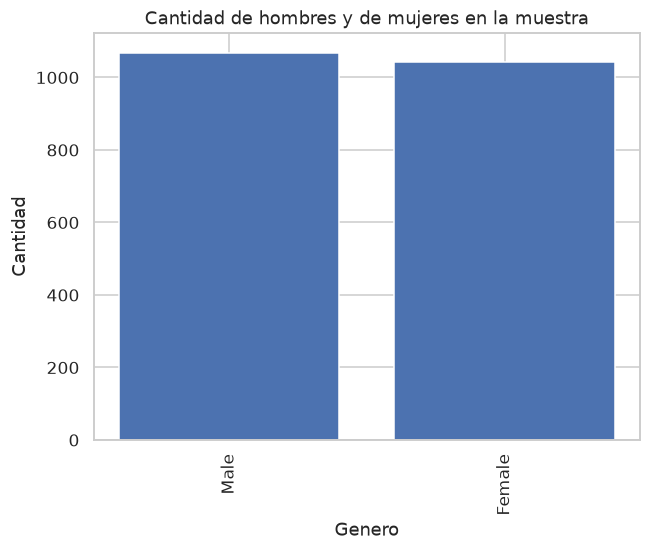

In [11]:
# TODO: Implementar análisis y visualización 1.a
conteo_genero = df_obesity['Gender'].value_counts()

# Crear el gráfico de barras
plt.bar(conteo_genero.index, conteo_genero.values)

# Agregar etiquetas a los ejes
plt.xlabel("Genero")
plt.ylabel("Cantidad")

# Agregar un título al gráfico
plt.title(f"Cantidad de hombres y de mujeres en la muestra")
plt.xticks(rotation=90)  # Rotar las etiquetas del eje x para mejor visualización

# Mostrar el gráfico
plt.show()

### 1.b. Estudiar la proporción de consumidores de alcohol mujeres y hombres
- **Variables involucradas:** `Gender` (Cualitativa nominal) vs `CALC` (Cualitativa ordinal/nominal).
- **Técnica sugerida:** Tabla de contingencia cruzada normalizada por fila (`normalize='index'`) y gráfico de barras apiladas al 100% o agrupadas.

In [21]:
# TODO: Implementar análisis y visualización 1.b

#Como son 2 variables cualitativas, una buena idea es usar una tabla de contingencia cruzada

# 1. Tabla de proporciones normalizada por fila (género)
tabla_prop = pd.crosstab(df_obesity['Gender'], df_obesity['CALC'], normalize='index') * 100

# Ordenamos las columnas respetando la escala ordinal de consumo
categorias = ['no', 'Sometimes', 'Frequently', 'Always']
tabla_prop = tabla_prop.reindex(columns=categorias, fill_value=0)
tabla_prop

CALC,no,Sometimes,Frequently,Always
Gender,,,,
Female,29.146692,68.168744,2.684564,0.000000
Male,31.367041,64.606742,3.932584,0.093633


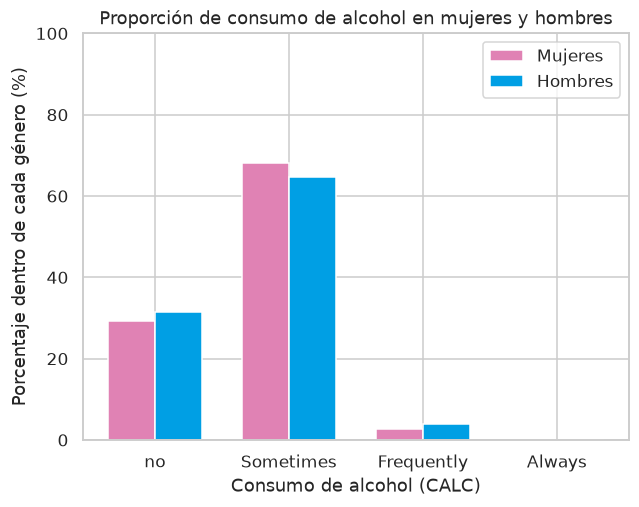

In [20]:
# 2. Obtenemos las alturas para cada serie
mujeres = tabla_prop.loc['Female']
hombres = tabla_prop.loc['Male']

# Definir posiciones y ancho de barras
x = range(len(categorias))
width = 0.35

# Barra de mujeres (desplazada a la izquierda)
plt.bar([i - width/2 for i in x], mujeres, width, label='Mujeres', color='#e082b4')

# Barra de hombres (desplazada a la derecha)
plt.bar([i + width/2 for i in x], hombres, width, label='Hombres', color='#009FE4')

# Configuración de ejes y etiquetas honestas
plt.xlabel("Consumo de alcohol (CALC)")
plt.ylabel("Porcentaje dentro de cada género (%)")
plt.title("Proporción de consumo de alcohol en mujeres y hombres")

# Restauramos los nombres de las categorías en el eje X
plt.xticks(x, categorias, rotation=0)

# Leyenda y límites honestos
plt.legend()
plt.ylim(0, 100) # Mostramos el rango completo de porcentaje

# Mostrar el canvas antes de cerrarlo
plt.show()

### 1.c. Estudiar la relación entre la edad y el peso
- **Variables involucradas:** `Age` vs `Weight` (Ambas Cuantitativas continuas).
- **Técnica sugerida:** Scatter Plot con relación de aspecto 1:1 (cuadrado) + Coeficiente de correlación (evaluar Pearson vs Spearman).

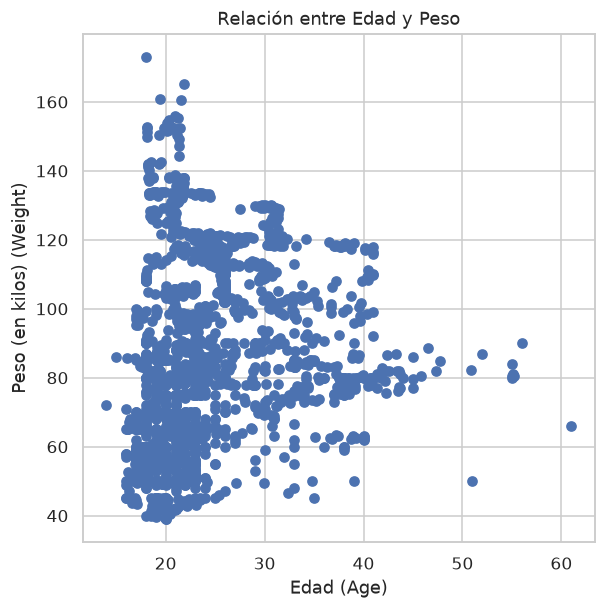

In [24]:
# TODO: Implementar análisis y visualización 1.c
# Crear el gráfico de dispersión
plt.figure(figsize=(6, 6))  # Hacer el gráfico cuadrado
plt.scatter(df_obesity["Age"], df_obesity["Weight"])

# Agregar etiquetas a los ejes
plt.xlabel("Edad (Age)")
plt.ylabel("Peso (en kilos) (Weight)")

# Agregar un título al gráfico
plt.title("Relación entre Edad y Peso")

# Mostrar el gráfico
plt.show()

### 1.d. Estudiar la relación entre peso y altura
- **Variables involucradas:** `Weight` vs `Height` (Cuantitativas continuas).
- **Técnica sugerida:** Scatter plot cuadrado + scatter con `hue='NObeyesdad'` para evaluar si la masa corporal segmenta naturalmente los grupos.

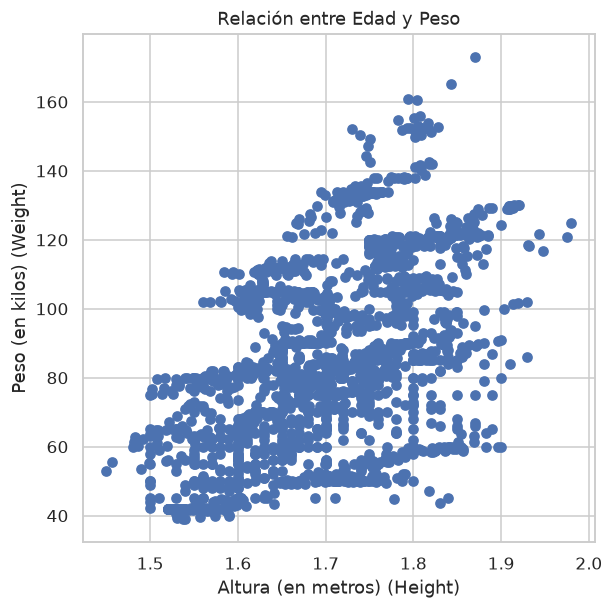

In [27]:
# TODO: Implementar análisis y visualización 1.c
# Crear el gráfico de dispersión
plt.figure(figsize=(6, 6))  # Hacer el gráfico cuadrado
plt.scatter(df_obesity["Height"], df_obesity["Weight"])

# Agregar etiquetas a los ejes
plt.xlabel("Altura (en metros) (Height)")
plt.ylabel("Peso (en kilos) (Weight)")

# Agregar un título al gráfico
plt.title("Relación entre Edad y Peso")

# Mostrar el gráfico
plt.show()

In [29]:
corr_pearson = df_obesity[['Height', 'Weight']].corr(method = 'pearson')
print(corr_pearson)

          Height    Weight
Height  1.000000  0.463136
Weight  0.463136  1.000000


### 1.e. Estudiar la relación entre obesidad y consumo de alcohol
- **Variables involucradas:** `NObeyesdad` (Cualitativa ordinal/nominal) vs `CALC` (Cualitativa ordinal).
- **Técnica sugerida:** Tabla de contingencia + Heatmap o barras agrupadas porcentuales + Test de Chi-cuadrado.

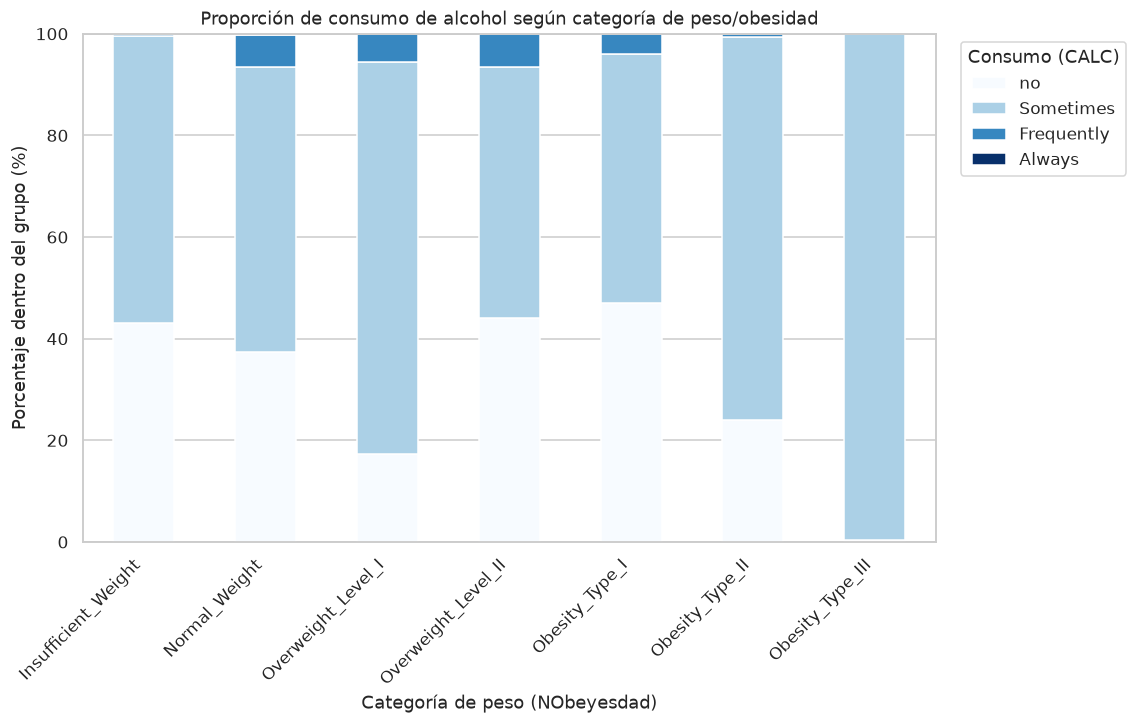

In [32]:
# TODO: Implementar análisis y visualización 1.e

# 1. Definir el orden natural de las categorías
orden_obesidad = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

orden_calc = ['no', 'Sometimes', 'Frequently', 'Always']

# Tabla de proporciones normalizada por fila (tipo de obesidad)
tabla_prop = pd.crosstab(df_obesity['NObeyesdad'], df_obesity['CALC'], normalize='index') * 100

# Reordenamos filas y columnas respetando el orden lógico
tabla_prop = tabla_prop.reindex(index=orden_obesidad, columns=orden_calc, fill_value=0)

# Graficar barras apiladas al 100%
tabla_prop.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Blues')

plt.title("Proporción de consumo de alcohol según categoría de peso/obesidad")
plt.xlabel("Categoría de peso (NObeyesdad)")
plt.ylabel("Porcentaje dentro del grupo (%)")
plt.xticks(rotation=45, ha='right')  # Rotación a 45° con alineación derecha para que no se pisen
plt.legend(title="Consumo (CALC)", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.ylim(0, 100)
plt.show()

In [31]:
df_obesity['CALC'].value_counts()


CALC
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64

### 1.f. Estudiar la proporción de edades en la muestra de mujeres y de hombres. ¿Son similares entre sí? Justificar.
- **Variables involucradas:** `Age` (Cuantitativa continua) condicionada por `Gender` (Cualitativa nominal).
- **Técnica sugerida:** Boxplots comparativos con `notch=True` (evaluar solapamiento de muescas) e histogramas / KDE superpuestos.

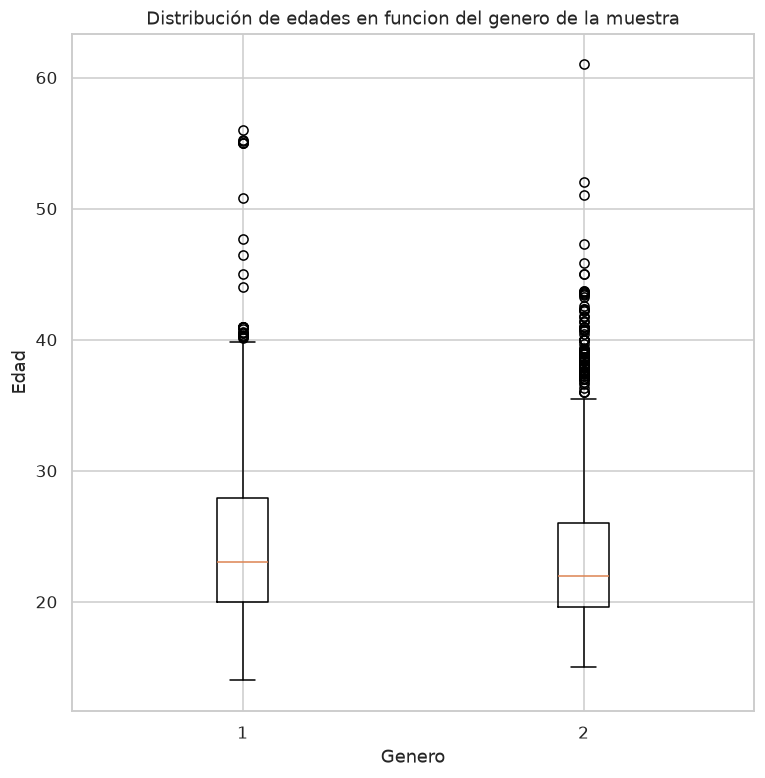

In [36]:
# TODO: Implementar análisis y visualización 1.f

import matplotlib.pyplot as plt

# Crear el boxplot
plt.figure(figsize=(8, 8))
plt.boxplot([df_obesity[df_obesity["Gender"] == "Male"]["Age"],
             df_obesity[df_obesity["Gender"] == "Female"]["Age"]
             ],label=["Hombre", "Mujer"])

# Agregar etiquetas a los ejes
plt.xlabel("Genero")
plt.ylabel("Edad")

# Agregar un título al gráfico
plt.title("Distribución de edades en funcion del genero de la muestra")

# Mostrar el gráfico
plt.show()


/tmp/ipykernel_22145/414939450.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_obesity, x="Gender", y="Age", notch=True, palette="Blues")


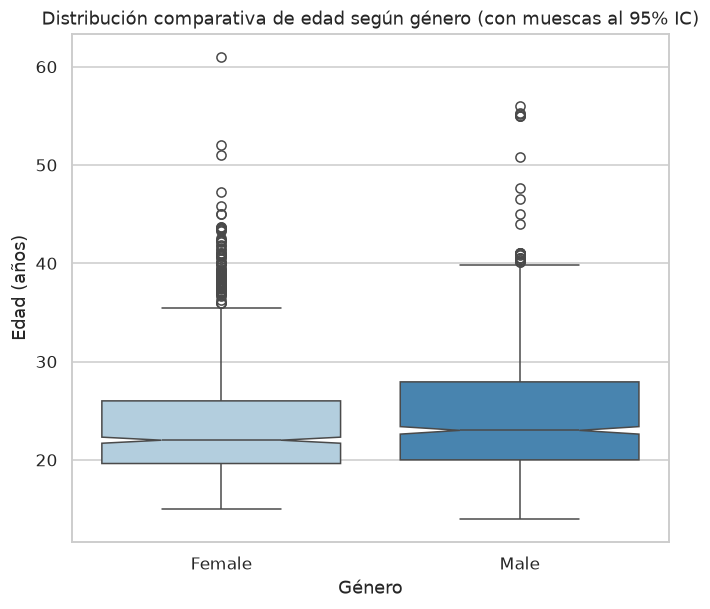

In [37]:
# TODO: Implementar análisis y visualización 1.f
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))

# Boxplot con muescas
sns.boxplot(data=df_obesity, x="Gender", y="Age", notch=True, palette="Blues")

# Rigor visual: etiquetas claras y título descriptivo
plt.xlabel("Género")
plt.ylabel("Edad (años)")
plt.title("Distribución comparativa de edad según género (con muescas al 95% IC)")

plt.show()

# Analisis
Ambas distribuciones presentan una marcada asimetria hacia la dercha (mediana cercana a Q1), con cajas intercuartilicas de 19-26anos en mujeres y 20-28 anos en hombres, y varios ooutliers hacia edades mayores


La media de edad en muejeres cae aproximadamente en 22. Pero nosotros estamos trabajando con una muestra, no podemos asegurar que se cumple para toda la poblacion de mujeres. Algo mas prudente podria agregar los las muescas. Nos van a dar un rango de seguridad, donde nosotros podemos afirmar con un 95% de seguridad que la media esta en ese rango.

Entonces ahora la media vive en un rango mas amplio. Pero fijate que ni siquiera con ese rango mas amplio las muescas se solapan entre boxplot. Entonces eso nos da confianza para pensar que las medias son efectivamente distintas. Lo que falta hacer es un test para verificar la hipotesis. 

Para considerar el test como valido, usamos un error < 5%. Entonces nuestro p valor debe ser menor a ese numero para rechazar la hipotesis nula.

In [39]:
from scipy import stats

# 1. Separamos las edades de cada grupo
edades_hombres = df_obesity[df_obesity["Gender"] == "Male"]["Age"]
edades_mujeres = df_obesity[df_obesity["Gender"] == "Female"]["Age"]

# 2. Ejecutamos el test
estadistico, p_valor = stats.mannwhitneyu(edades_hombres, edades_mujeres)

print(f"Estadístico U: {estadistico}")
print(f"p-valor: {p_valor:.4f}")

Estadístico U: 600835.0
p-valor: 0.0017


### 1.g. Estudiar los valores de peso según la variable categoría de obesidad. ¿Qué puede decirse de ellas?
- **Variables involucradas:** `Weight` (Cuantitativa continua) vs `NObeyesdad` (Cualitativa ordinal/nominal).
- **Técnica sugerida:** Boxplots con categorías ordenadas por nivel de peso y análisis de varianza / outliers.

/tmp/ipykernel_22145/1972660814.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


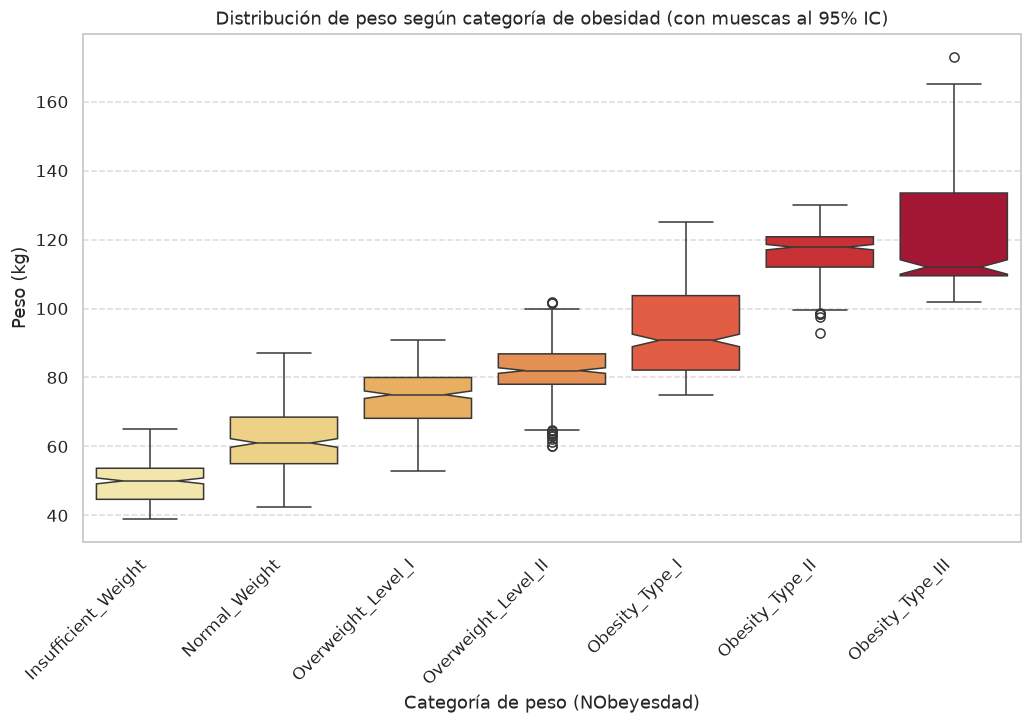

                     count    mean    std     25%     50%     75%    max
NObeyesdad                                                              
Insufficient_Weight  272.0   49.91   6.01   44.66   50.00   53.67   65.0
Normal_Weight        287.0   62.16   9.30   55.00   61.00   68.50   87.0
Overweight_Level_I   290.0   74.27   8.47   68.15   75.00   80.00   91.0
Overweight_Level_II  290.0   82.09   8.45   78.03   82.00   86.85  102.0
Obesity_Type_I       351.0   92.87  11.49   82.14   90.74  103.74  125.0
Obesity_Type_II      297.0  115.31   8.02  112.01  117.79  120.81  130.0
Obesity_Type_III     324.0  120.94  15.53  109.49  112.05  133.50  173.0


In [40]:

# TODO: Implementar análisis y visualización 1.g
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir el orden natural de menor a mayor peso
orden_obesidad = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

# 2. Configurar el canvas y generar el Boxplot
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df_obesity,
    x="NObeyesdad",
    y="Weight",
    order=orden_obesidad,
    notch=True,
    palette="YlOrRd"  # Paleta secuencial intuitiva: de menor riesgo (amarillo) a mayor (rojo)
)

# Configuración de estética y etiquetas honestas
plt.title("Distribución de peso según categoría de obesidad (con muescas al 95% IC)")
plt.xlabel("Categoría de peso (NObeyesdad)")
plt.ylabel("Peso (kg)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# 3. Resumen numérico complementario para tu análisis
resumen_peso = df_obesity.groupby('NObeyesdad')['Weight'].describe().reindex(orden_obesidad)
print(resumen_peso[['count', 'mean', 'std', '25%', '50%', '75%', 'max']].round(2))

In [ ]:
# Analisis

Analisis:
El boxplot del peso normal se observa bastante simetrico, como una distribucion normal.

El peso insuficiente tiene poca dispersion, los valores son cercanos entre si, el rango intercuartilico esta muy concentrado entrre 45 a 55 kilos.

Mientras que la obesidad tipo 3 tiene una dispersion mayor (esto lo digo por la altura del bigote superior) y porque tiene el mayor rango intercuartilico de 110 a 134. Aunque no se si puedo afirmar eso siendo que el q2 (112) esta casi encimado con q1, es muy sorprendente.
Es curioso que al ver la mediana de la obesidad de tipo 2 se encuentre por encima que la de tipo 3.

Entonces vale la pena analizar un poco mas


In [44]:
tabla_prop = pd.crosstab(df_obesity['NObeyesdad'], df_obesity['Gender'])
print(tabla_prop)

Gender               Female  Male
NObeyesdad                       
Insufficient_Weight     173    99
Normal_Weight           141   146
Obesity_Type_I          156   195
Obesity_Type_II           2   295
Obesity_Type_III        323     1
Overweight_Level_I      145   145
Overweight_Level_II     103   187


In [ ]:
Mira resulta que en obesidad tipo 2 son todos hombres. Y en obesidad tipo 3 son todas mujeres
Porque para caer en cada categoria hay que tener en cuenta la altura.
Entonces las mujeres petisas que pesan 110k entran en obesidad tipo 3.
Y los hombres altos que pesan 110k entran en obesidad tipo 2, empujando la mediana hacia arriba. 

### 1.h. Estudiar la relación entre el consumo de vegetales y la obesidad
- **Variables involucradas:** `FCVC` (Frecuencia de consumo de vegetales, ordinal/discreta) vs `NObeyesdad`.

In [47]:
df_obesity = df_obesity[df_obesity['NObeyesdad'] == 'Obesity_Type_III']
df_obesity.head()


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad,FCVC_cat,FCVC_desc
202,26.000000,Female,1.560000,102.000000,Sometimes,yes,3.0,3.0,no,yes,1.000000,yes,0.000000,1.0,Sometimes,Public_Transportation,Obesity_Type_III,3,3 (Siempre)
344,18.000000,Male,1.870000,173.000000,Sometimes,yes,3.0,3.0,no,no,2.000000,yes,2.000000,1.0,Frequently,Public_Transportation,Obesity_Type_III,3,3 (Siempre)
403,26.000000,Female,1.660000,112.000000,no,no,3.0,3.0,no,no,3.000000,yes,0.000000,0.0,Sometimes,Automobile,Obesity_Type_III,3,3 (Siempre)
498,25.196214,Female,1.686306,104.572712,Sometimes,yes,3.0,3.0,no,no,1.152736,yes,0.319156,1.0,Sometimes,Public_Transportation,Obesity_Type_III,3,3 (Siempre)
499,18.503343,Female,1.683124,126.673780,Sometimes,yes,3.0,3.0,no,no,1.115967,yes,1.541072,1.0,Sometimes,Public_Transportation,Obesity_Type_III,3,3 (Siempre)


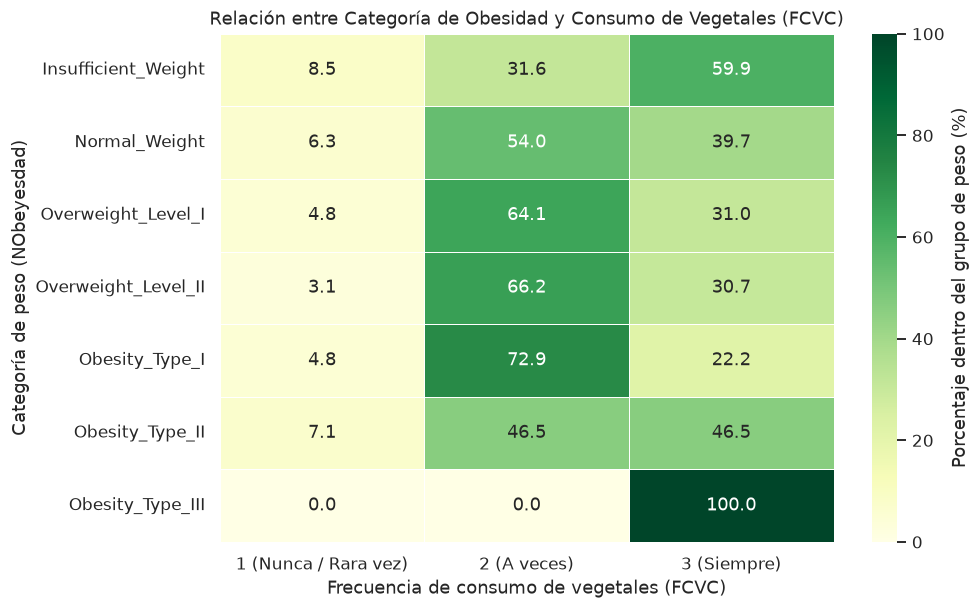

In [45]:
# TODO: Implementar análisis y visualización 1.h

# TODO: Implementar análisis y visualización 1.h
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Discretizar FCVC a sus 3 niveles ordinales originales
df_obesity['FCVC_cat'] = df_obesity['FCVC'].round().astype(int)

# Etiquetas legibles para las columnas
mapeo_fcvc = {
    1: '1 (Nunca / Rara vez)',
    2: '2 (A veces)',
    3: '3 (Siempre)'
}
df_obesity['FCVC_desc'] = df_obesity['FCVC_cat'].map(mapeo_fcvc)

# 2. Orden natural de menor a mayor peso
orden_obesidad = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

orden_columnas_fcvc = [
    '1 (Nunca / Rara vez)',
    '2 (A veces)',
    '3 (Siempre)'
]

# 3. Tabla de proporciones normalizada por fila (% dentro de cada tipo de peso)
tabla_fcvc = pd.crosstab(
    df_obesity['NObeyesdad'],
    df_obesity['FCVC_desc'],
    normalize='index'
) * 100

# Reordenamos filas y columnas
tabla_fcvc = tabla_fcvc.reindex(index=orden_obesidad, columns=orden_columnas_fcvc)

# 4. Graficar el Heatmap
plt.figure(figsize=(9, 6))

sns.heatmap(
    tabla_fcvc,
    annot=True,          # Muestra el número adentro de cada celda
    fmt=".1f",           # Formato con un solo decimal
    cmap="YlGn",         # Paleta amarillo-verde (intuitiva para vegetales)
    cbar_kws={'label': 'Porcentaje dentro del grupo de peso (%)'},
    linewidths=0.5       # Líneas sutiles entre celdas para separar
)

plt.title("Relación entre Categoría de Obesidad y Consumo de Vegetales (FCVC)")
plt.xlabel("Frecuencia de consumo de vegetales (FCVC)")
plt.ylabel("Categoría de peso (NObeyesdad)")
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.show()

---
## Ejercicio 2: Catálogo de Streaming (Netflix)
Dataset: `netflix_titles.csv`

In [61]:
df_netflix = pd.read_csv('netflix_titles.csv')
print(f"Dimensiones: {df_netflix.shape}")
df_netflix.head(3)

# Eliminamos columnas que sean 100% nulas
df_netflix = df_netflix.dropna(axis=1, how='all')

print(f"Nuevas dimensiones: {df_netflix.shape}")
print(f"Columnas legítimas: {list(df_netflix.columns)}")

Dimensiones: (8809, 26)
Nuevas dimensiones: (8809, 12)
Columnas legítimas: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


### 2.a & 2.b. Número de películas y TV Shows según su año de lanzamiento
- **Variables involucradas:** `release_year` (Cuantitativa discreta / serie temporal) y `type` (Cualitativa nominal).
- **Técnica sugerida:** Gráfico de líneas temporal con separación por tipo y anotación de hitos (ej. auge del streaming).

In [62]:
# TODO: Implementar análisis y visualización 2.a y 2.b
conteo_tipo = pd.crosstab(df_netflix['release_year'], df_netflix['type'])

print(conteo_tipo)

type          Movie  TV Show
release_year                
1925              0        1
1942              2        0
1943              3        0
1944              3        0
1945              3        1
...             ...      ...
2018            767      380
2019            633      397
2020            517      436
2021            277      315
2024              0        1

[75 rows x 2 columns]


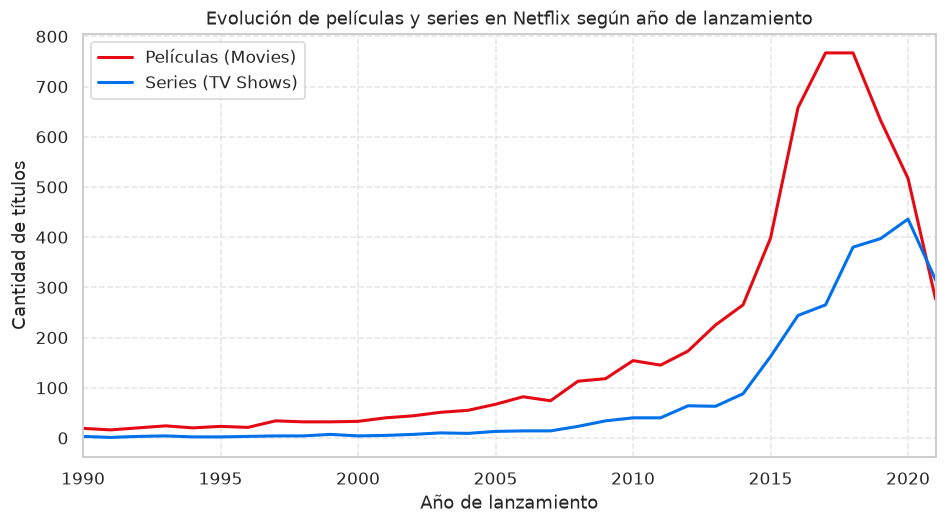

In [63]:
# TODO: Implementar análisis y visualización 2.a y 2.b
import matplotlib.pyplot as plt
import pandas as pd

# 1. Agrupar la cantidad de títulos por año y tipo
conteo_tipo = pd.crosstab(df_netflix['release_year'], df_netflix['type'])

# 2. Configurar el gráfico
plt.figure(figsize=(10, 5))

# Línea para Películas
plt.plot(
    conteo_tipo.index, 
    conteo_tipo['Movie'], 
    label='Películas (Movies)', 
    color='#e50914',      # Rojo característico de Netflix
    linewidth=2
)

# Línea para Series (TV Shows)
plt.plot(
    conteo_tipo.index, 
    conteo_tipo['TV Show'], 
    label='Series (TV Shows)', 
    color='#0071eb',      # Azul para contrastar
    linewidth=2
)

# 3. Etiquetas, título y leyenda
plt.title("Evolución de películas y series en Netflix según año de lanzamiento")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Cantidad de títulos")
plt.legend()             # Muestra la cajita con los nombres y colores
plt.grid(True, linestyle='--', alpha=0.5)

# Opcional: Acotar el eje X desde 1990 para hacer foco en el auge reciente
plt.xlim(1990, 2021)

plt.show()

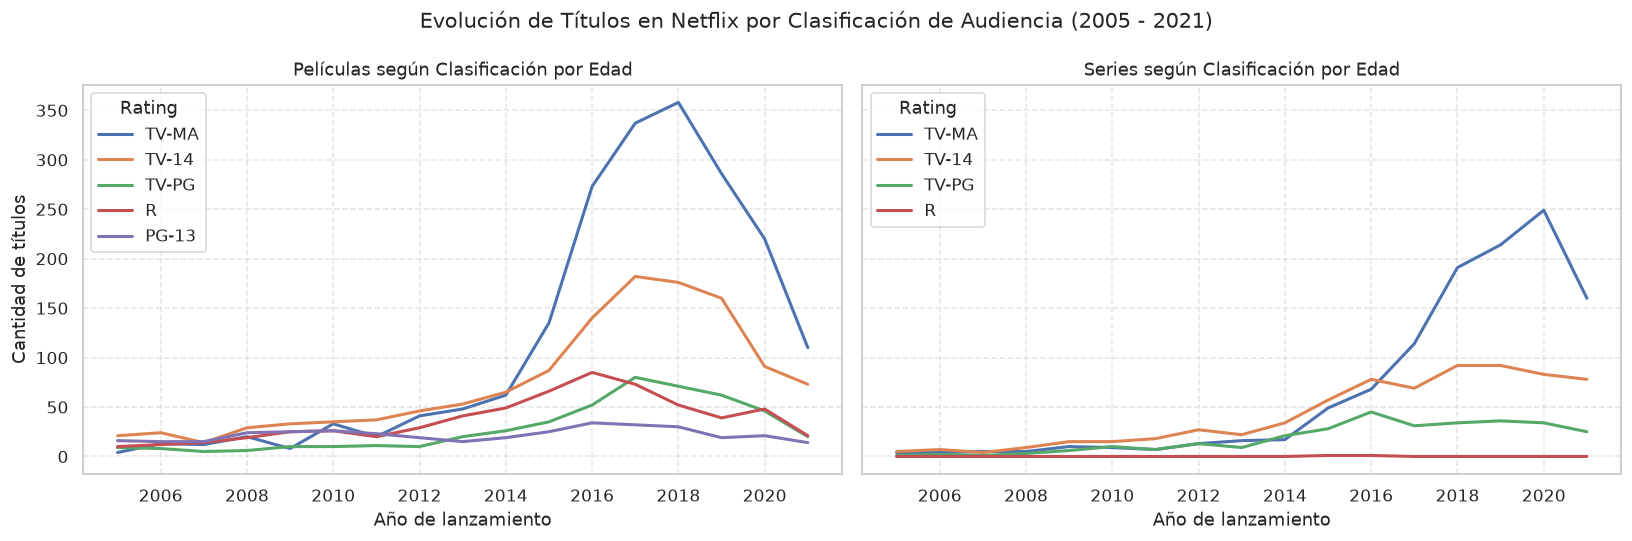

In [64]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filtramos las clasificaciones principales y años recientes (ej. desde 2005)
ratings_top = ['TV-MA', 'TV-14', 'TV-PG', 'R', 'PG-13']
df_filtrado = df_netflix[
    (df_netflix['rating'].isin(ratings_top)) & 
    (df_netflix['release_year'] >= 2005) & 
    (df_netflix['release_year'] <= 2021)
]

# 2. Separar películas y series
peliculas = df_filtrado[df_filtrado['type'] == 'Movie']
series = df_filtrado[df_filtrado['type'] == 'TV Show']

# Contar por año y rating
peli_rating = pd.crosstab(peliculas['release_year'], peliculas['rating'])
serie_rating = pd.crosstab(series['release_year'], series['rating'])

# 3. Crear 2 gráficos lado a lado (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Gráfico 1: Películas
for r in ratings_top:
    if r in peli_rating.columns:
        ax1.plot(peli_rating.index, peli_rating[r], label=r, linewidth=2)

ax1.set_title("Películas según Clasificación por Edad")
ax1.set_xlabel("Año de lanzamiento")
ax1.set_ylabel("Cantidad de títulos")
ax1.legend(title="Rating")
ax1.grid(True, linestyle='--', alpha=0.5)

# Gráfico 2: Series
for r in ratings_top:
    if r in serie_rating.columns:
        ax2.plot(serie_rating.index, serie_rating[r], label=r, linewidth=2)

ax2.set_title("Series según Clasificación por Edad")
ax2.set_xlabel("Año de lanzamiento")
ax2.legend(title="Rating")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Evolución de Títulos en Netflix por Clasificación de Audiencia (2005 - 2021)", fontsize=14)
plt.tight_layout()
plt.show()

### 2.c. Cantidad de películas y TV Shows según su rating
- **Variables involucradas:** `rating` (Cualitativa ordinal/nominal) vs `type`.
- **Técnica sugerida:** Gráfico de barras agrupadas o apiladas ordenadas por frecuencia.

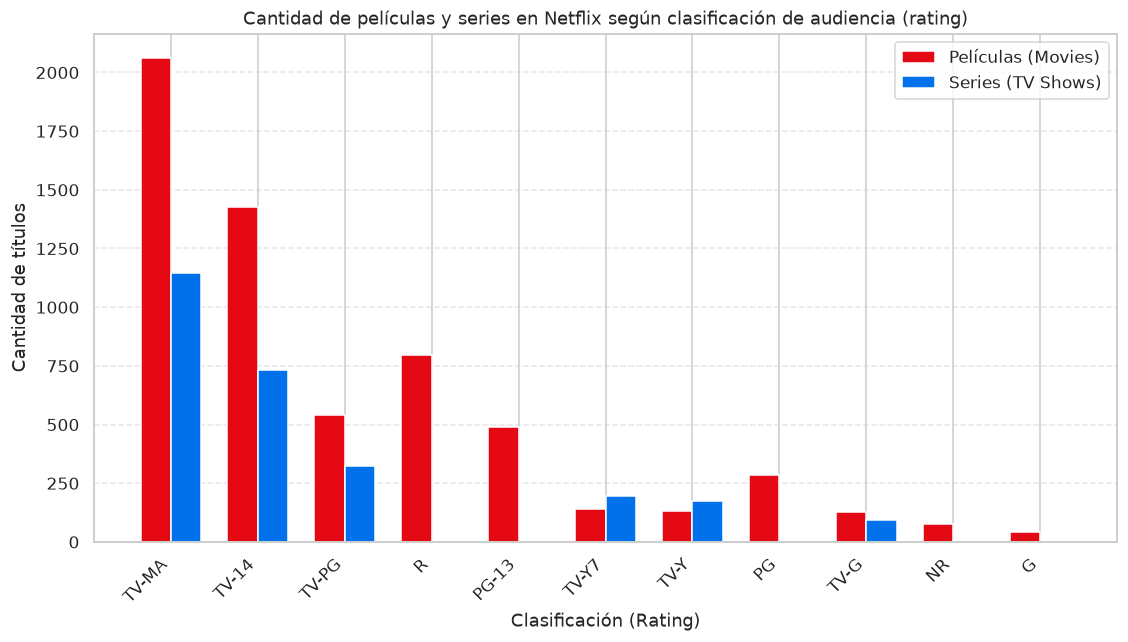

In [65]:
# TODO: Implementar análisis y visualización 2.c
# TODO: Implementar análisis y visualización 2.c
import matplotlib.pyplot as plt
import pandas as pd

# 1. Limpiar ratings nulos y errores de scraping
df_valid_ratings = df_netflix[
    df_netflix['rating'].notna() & 
    (~df_netflix['rating'].str.contains('min', na=False))
]

# 2. Tabla de contingencia entre rating y type
tabla_rating = pd.crosstab(df_valid_ratings['rating'], df_valid_ratings['type'])

# 3. Ordenar por frecuencia total (de mayor a menor para ranking)
# Si preferís de menor a mayor, cambiás a ascending=True
tabla_rating['Total'] = tabla_rating.sum(axis=1)
tabla_rating = tabla_rating.sort_values(by='Total', ascending=False)

# Opcional: Nos quedamos con los ratings que tengan al menos 10 títulos para no ensuciar el gráfico con categorías ínfimas
tabla_rating = tabla_rating[tabla_rating['Total'] >= 10]

# 4. La magia de las barras agrupadas
categorias = tabla_rating.index
x = range(len(categorias))
width = 0.35

plt.figure(figsize=(12, 6))

# Barra Películas (desplazada a la izquierda)
plt.bar(
    [i - width/2 for i in x], 
    tabla_rating['Movie'], 
    width=width, 
    label='Películas (Movies)', 
    color='#e50914'
)

# Barra Series (desplazada a la derecha)
plt.bar(
    [i + width/2 for i in x], 
    tabla_rating['TV Show'], 
    width=width, 
    label='Series (TV Shows)', 
    color='#0071eb'
)

# 5. Configuración de canvas y rotación honesta
plt.title("Cantidad de películas y series en Netflix según clasificación de audiencia (rating)")
plt.xlabel("Clasificación (Rating)")
plt.ylabel("Cantidad de títulos")
plt.xticks(x, categorias, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### 2.d. Relación entre rating y duración de la película / serie
- **Variables involucradas:** `rating` (Cualitativa) vs `duration` (Requiere separar minutos de temporadas).

/tmp/ipykernel_22145/3485073145.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


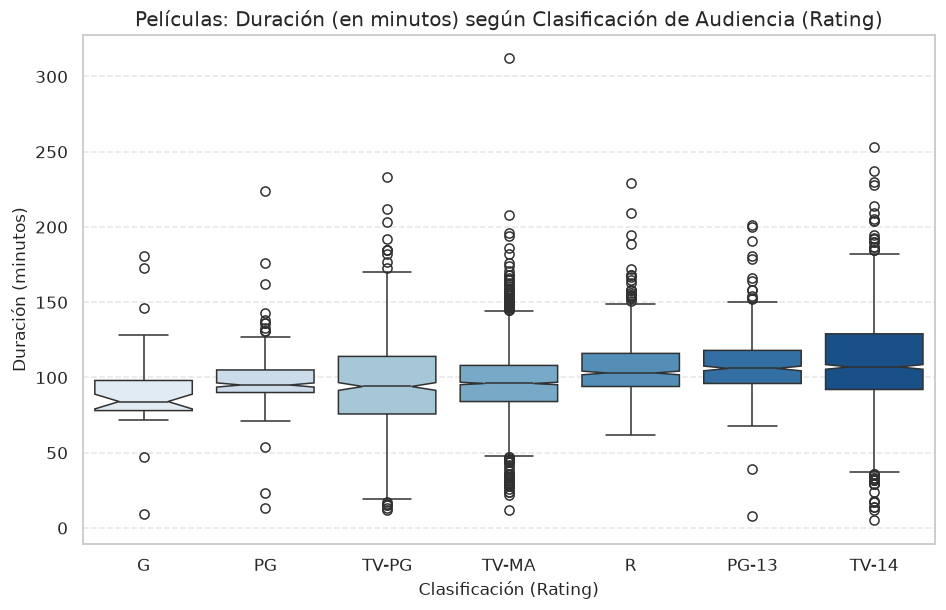

In [66]:
# TODO: Implementar análisis y visualización 2.d
# 2.d - Parte 1: Duración de PELÍCULAS (en minutos) según Rating
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Filtrar películas y extraer minutos como número
peliculas = df_netflix[df_netflix['type'] == 'Movie'].copy()
peliculas['minutos'] = peliculas['duration'].str.extract(r'(\d+)').astype(float)

# 2. Seleccionar los ratings más representativos de cine ordenados
ratings_cine = ['G', 'PG', 'TV-PG', 'TV-MA', 'R', 'PG-13', 'TV-14']
peliculas_filtradas = peliculas[peliculas['rating'].isin(ratings_cine)]

# 3. Gráfico Boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=peliculas_filtradas,
    x='rating',
    y='minutos',
    order=ratings_cine,
    palette='Blues',
    notch=True
)

plt.title("Películas: Duración (en minutos) según Clasificación de Audiencia (Rating)", fontsize=13)
plt.xlabel("Clasificación (Rating)", fontsize=11)
plt.ylabel("Duración (minutos)", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

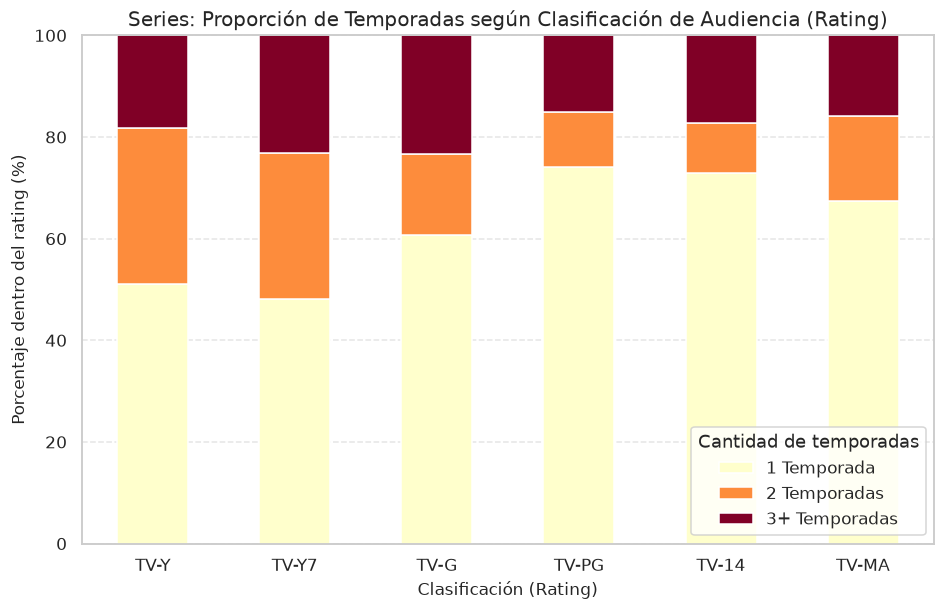

In [67]:
# 2.d - Parte 2: Duración de SERIES (en temporadas) según Rating
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filtrar series y extraer número de temporadas
series = df_netflix[df_netflix['type'] == 'TV Show'].copy()
series['temporadas'] = series['duration'].str.extract(r'(\d+)').astype(float)

# 2. Agrupar las temporadas para facilitar la lectura
series['grupo_temporadas'] = pd.cut(
    series['temporadas'],
    bins=[0, 1, 2, 100],
    labels=['1 Temporada', '2 Temporadas', '3+ Temporadas']
)

# 3. Filtrar ratings principales de series
ratings_series = ['TV-Y', 'TV-Y7', 'TV-G', 'TV-PG', 'TV-14', 'TV-MA']
series_filtradas = series[series['rating'].isin(ratings_series)]

# 4. Tabla de contingencia en porcentajes normalizada por rating
prop_series = pd.crosstab(
    series_filtradas['rating'], 
    series_filtradas['grupo_temporadas'], 
    normalize='index'
).reindex(ratings_series) * 100

# 5. Gráfico de barras apiladas al 100%
ax = prop_series.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='YlOrRd'
)

plt.title("Series: Proporción de Temporadas según Clasificación de Audiencia (Rating)", fontsize=13)
plt.xlabel("Clasificación (Rating)", fontsize=11)
plt.ylabel("Porcentaje dentro del rating (%)", fontsize=11)
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title="Cantidad de temporadas", loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### 2.e. Cantidad de palabras en la descripción y su relación con el rating
- **Variables involucradas:** Longitud en palabras de `description` (Cuantitativa discreta) vs `rating`.

### 2.f. Número de películas y TV Shows por país de origen
- **Variables:** `country` (Cualitativa con múltiples valores por celda, requiere manejo cuidadoso de `.explode()` y top N países).

In [68]:
# TODO: Implementar análisis y visualización 2.f


### 2.g. Cantidad de contenidos por actor del casting (Top 10 actores/actrices)
- **Variables:** `cast` (Cadena de nombres separados por coma, requiere separación y ranking con color focus).

In [69]:
# TODO: Implementar análisis y visualización 2.g